# Setup & Mount Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = '/content/drive/MyDrive/Colab Notebooks/SkyFinder'
RAW  = f'{BASE}/raw_zips'
IMG  = f'{BASE}/images'
META = f'{BASE}/metadata'

os.makedirs(RAW, exist_ok=True)
os.makedirs(IMG, exist_ok=True)
os.makedirs(META, exist_ok=True)

print(BASE)

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/SkyFinder


In [ ]:
!pip install -q zenodo_get pandas pillow tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.2/254.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.1 MB/s eta 0:00:00


In [ ]:
!ls /content/drive
!ls /content/drive/MyDrive
!ls "/content/drive/MyDrive/Colab Notebooks"

MyDrive
'Colab Notebooks'   SkyFinderTemperatureRegression.ipynb
SkyFinder  SkyFinderTemperatureRegression.ipynb


In [ ]:
%%bash
set -e

BASE="/content/drive/MyDrive/Colab Notebooks/SkyFinder/raw_zips"

mkdir -p "$BASE"
cd "$BASE"

echo "Current directory:"
pwd

for id in 65 75 162 204 260 623 684 858 861 1093 3297 3395 3396 3837 3888 \
4181 4232 4584 4679 4795 4801 5020 5021 6798 7211 7233 7371 8438 8733 \
8887 8953 9112 9291 9483 9708 9730 10066 10870 10917 11160 11331 17218 \
17244 18590 19106 19306 19388 19834 21444 21510 21511 22788 24325
do
  echo "Downloading ${id}.zip ..."
  wget -q -c https://zenodo.org/record/5884485/files/${id}.zip || { echo "Failed: ${id}.zip"; exit 1; }
done

echo "Download finished."

echo "Files in directory:"
ls -lh

Current directory:
/content/drive/MyDrive/Colab Notebooks/SkyFinder/raw_zips
Download finished.
Files in directory:
total 9.8G
-rw------- 1 root root  68M Apr 24 03:30 10066.zip
-rw------- 1 root root  68M Apr 24 03:31 10870.zip
-rw------- 1 root root 527M Apr 24 03:31 10917.zip
-rw------- 1 root root  31M Apr 24 03:29 1093.zip
-rw------- 1 root root 217M Apr 24 03:31 11160.zip
-rw------- 1 root root  83M Apr 24 03:31 11331.zip
-rw------- 1 root root 382M Apr 24 03:28 162.zip
-rw------- 1 root root  54M Apr 24 03:31 17218.zip
-rw------- 1 root root 311M Apr 24 03:31 17244.zip
-rw------- 1 root root 489M Apr 24 03:31 18590.zip
-rw------- 1 root root  40M Apr 24 03:31 19106.zip
-rw------- 1 root root 459M Apr 24 03:31 19306.zip
-rw------- 1 root root 278M Apr 24 03:32 19388.zip
-rw------- 1 root root  77M Apr 24 03:33 19834.zip
-rw------- 1 root root  66M Apr 24 03:28 204.zip
-rw------- 1 root root  42M Apr 24 03:33 21444.zip
-rw------- 1 root root 326M Apr 24 03:33 21510.zip
-rw------- 

In [ ]:
# Unzip
%%bash
cd "/content/drive/MyDrive/Colab Notebooks/SkyFinder/raw_zips"

mkdir -p ../images

for f in *.zip; do
  unzip -q -n "$f" -d ../images
done

In [ ]:
# Load Metadata
import pandas as pd

META = "/content/drive/MyDrive/Colab Notebooks/SkyFinder/metadata"

meta_path = f"{META}/metadata.csv"

df = pd.read_csv(meta_path)
print(df.columns)
df.head()

Index(['Filename', 'CamId', 'Year', 'hoiem_MCR', 'hoiem_Accuracy',
       'svetlana2010_MCR', 'svetlana2010_Accuracy', 'tcwc_MCR',
       'tcwc_Accuracy', 'Date', 'Latitude', 'Longitude', 'Month', 'Day',
       'Timezone', 'Hour', 'Min', 'TempM', 'TempI', 'DewPtM', 'DewPtI', 'Hum',
       'WspdM', 'WspdI', 'WgustM', 'WgustI', 'WDirD', 'WDirE', 'VisM', 'VisI',
       'PressureM', 'PressureI', 'WindChillM', 'WindChillI', 'HeatIndexM',
       'HeatIndexI', 'PrecipM', 'PrecipI', 'Conds', 'Icon', 'Fog', 'Rain',
       'Snow', 'Hail', 'Thunder', 'Tornado', 'Metar', 'dirty', 'daylight',
       'night', 'sunrisesunset', 'dawndusk', 'sunny', 'clouds', 'fog', 'storm',
       'snow', 'warm', 'cold', 'busy', 'beautiful', 'flowers', 'spring',
       'summer', 'autumn', 'winter', 'glowing', 'colorful', 'dull', 'rugged',
       'midday', 'dark', 'bright', 'dry', 'moist', 'windy', 'rain', 'ice',
       'cluttered', 'soothing', 'stressful', 'exciting', 'sentimental',
       'mysterious', 'boring', 'glo

,Filename,CamId,Year,hoiem_MCR,hoiem_Accuracy,svetlana2010_MCR,svetlana2010_Accuracy,tcwc_MCR,tcwc_Accuracy,Date,...,ice,cluttered,soothing,stressful,exciting,sentimental,mysterious,boring,gloomy,lush
0,20130101_091628.jpg,10066,2013,0.100599,0.899401,0.083451,0.916549,0.352917,0.647083,735235.428102,...,0.201019,0.578970,0.175610,0.465193,0.115777,0.194916,0.091037,0.574105,0.475860,0.084300
1,20130101_114638.jpg,10066,2013,0.096901,0.903099,0.017214,0.982786,0.379089,0.620911,735235.532384,...,0.216055,0.620019,0.227166,0.327942,0.211095,0.264720,0.075191,0.467294,0.376086,0.124136
2,20130101_125725.jpg,10066,2013,0.107018,0.892982,0.075417,0.924583,0.467018,0.532982,735235.581539,...,0.172771,0.587002,0.290493,0.327276,0.248607,0.262659,0.165920,0.492840,0.335585,0.182317
3,20130101_154632.jpg,10066,2013,0.103177,0.896823,0.050664,0.949336,0.041107,0.958893,735235.698981,...,0.340141,0.560550,0.333954,0.403318,0.256928,0.242259,0.191882,0.447818,0.398973,0.158941
4,20130102_092726.jpg,10066,2013,0.076693,0.923307,0.099089,0.900911,0.074622,0.925378,735236.435718,...,0.661996,0.599993,0.269088,0.339950,0.205382,0.313981,0.353019,0.400919,0.289538,0.158939


In [ ]:
"""Data validation for SkyFinder metadata before building the training CSV.

We verify three things:
    1. Temperature units — is TempM really in Celsius?
    2. Data quality   — how many rows have missing / sentinel values?
    3. File alignment — do filenames in the CSV resolve to real JPEGs on disk?
"""
import pandas as pd
import numpy as np
from pathlib import Path

META = "/content/drive/MyDrive/Colab Notebooks/SkyFinder/metadata"
df = pd.read_csv(f"{META}/metadata.csv")

# ---------------------------------------------------------------------------
# 1. Basic dataset inventory
# ---------------------------------------------------------------------------
print(f"Total rows: {len(df):,}")
print(f"Cameras:    {df['CamId'].nunique()}")
print("\nImages per camera (top 10):")
print(df['CamId'].value_counts().head(10))

# ---------------------------------------------------------------------------
# 2. Verify TempM is in Celsius by cross-checking against TempI (Fahrenheit).
#    Expected relation: TempI = TempM * 9/5 + 32.
# ---------------------------------------------------------------------------
sample = df.dropna(subset=['TempM', 'TempI']).head(1000)
predicted_F = sample['TempM'] * 9 / 5 + 32
mean_abs_diff = (predicted_F - sample['TempI']).abs().mean()
print(f"\n|TempM*9/5+32  -  TempI|  mean = {mean_abs_diff:.3f}  (≈0 confirms Celsius)")

# ---------------------------------------------------------------------------
# 3. Identify missing / sentinel values. SkyFinder uses -9999 for "unknown",
#    which is far below absolute zero (-273.15 °C), so we filter anything
#    physically impossible.
# ---------------------------------------------------------------------------
bad = (df['TempM'] <= -273.15) | (df['TempM'].isna())
print(f"\nRows with missing or sentinel (-9999) TempM: {bad.sum():,}  "
      f"({100 * bad.mean():.2f}% of total)")
print(f"Usable rows after filtering:                  {(~bad).sum():,}")

valid = df.loc[~bad, 'TempM']
print("\n=== Cleaned TempM distribution (°C) ===")
print(valid.describe())
print(f"\nExtreme tails (will be rare-bin in DIR):")
print(f"  < -30 °C : {(valid < -30).sum()}")
print(f"  > +50 °C : {(valid > 50).sum()}")

# ---------------------------------------------------------------------------
# 4. Verify CSV filenames resolve to real files on disk.
# ---------------------------------------------------------------------------
IMG_ROOT = Path('/content/drive/MyDrive/skyfinder-dir/images')
if IMG_ROOT.exists():
    cam_dirs = sorted([d.name for d in IMG_ROOT.iterdir() if d.is_dir()])
    print(f"\nExtracted camera directories: {len(cam_dirs)} found "
          f"(e.g. {cam_dirs[:5]}...)")
    if cam_dirs:
        test_cam = cam_dirs[0]
        cam_rows = df[df['CamId'].astype(str) == test_cam].head(5)
        print(f"\nSpot-check for camera {test_cam}:")
        for _, row in cam_rows.iterrows():
            fp = IMG_ROOT / test_cam / row['Filename']
            marker = "OK " if fp.exists() else "MISS"
            print(f"  [{marker}] {row['Filename']}")
else:
    print(f"\n[!] Image directory not found at {IMG_ROOT}. "
          f"Run the search cell below to locate the actual path.")

Total rows: 94,803
Cameras:    53

Images per camera (top 10):
CamId
684      4091
623      3741
10917    3568
18590    3491
65       3252
162      3246
260      3225
3837     3197
8887     3190
21510    2967
Name: count, dtype: int64

|TempM*9/5+32  -  TempI|  mean = 0.163  (≈0 confirms Celsius)

Rows with missing or sentinel (-9999) TempM: 335  (0.35% of total)
Usable rows after filtering:                  94,468

=== Cleaned TempM distribution (°C) ===
count    94468.000000
mean        14.099665
std          9.973120
min        -27.200000
25%          7.000000
50%         15.000000
75%         21.100000
max         50.000000
Name: TempM, dtype: float64

Extreme tails (will be rare-bin in DIR):
  < -30 °C : 0
  > +50 °C : 0

[!] Image directory not found at /content/drive/MyDrive/skyfinder-dir/images. Run the search cell below to locate the actual path.


# Data Preprocess


In [ ]:
# ============================================================================
# Preprocess — build skyfinder_clean.csv
# ----------------------------------------------------------------------------
# Reads raw metadata.csv, filters out bad rows, resolves full image paths,
# writes a clean CSV with only the columns downstream code needs.
#
# Output columns (11):
#   image_path, Filename, camera_id, Year, Month, Day, Hour, Min,
#   Latitude, Longitude, temperature_c
# ============================================================================
import pandas as pd
import numpy as np
from pathlib import Path

BASE     = "/content/drive/MyDrive/Colab Notebooks/SkyFinder"
META_CSV = f"{BASE}/metadata/metadata.csv"
IMG_ROOT = Path("/content/skyfinder_images")
OUT_DIR  = Path(f"{BASE}/data")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_CSV = OUT_DIR / "skyfinder_clean.csv"

# ---- 1. Load raw metadata -----------------------------------------------
df = pd.read_csv(META_CSV)
print(f"Raw rows: {len(df):,}")
print(f"Columns:  {list(df.columns)}")

# ---- 2. Filter bad temperature rows -------------------------------------
# SkyFinder uses -9999 as sentinel for "unknown". Anything below absolute
# zero is physically impossible. Also drop NaN.
bad = (df["TempM"] <= -273.15) | (df["TempM"].isna())
print(f"Dropping {bad.sum():,} rows with missing / sentinel TempM "
      f"({100*bad.mean():.2f}%)")
df = df.loc[~bad].copy()
print(f"After temp filter: {len(df):,} rows")

# ---- 3. Build full image paths; drop rows whose files don't exist -------
df["image_path"] = df.apply(
    lambda r: str(IMG_ROOT / str(r["CamId"]) / r["Filename"]),
    axis=1,
)

# Check existence on disk. Drive listing is slow, so do this per-camera
# instead of per-file to avoid thousands of individual stat() calls.
cam_to_files = {}
for cam_dir in IMG_ROOT.iterdir():
    if cam_dir.is_dir():
        cam_to_files[cam_dir.name] = set(f.name for f in cam_dir.iterdir())

print(f"Found {len(cam_to_files)} camera directories on disk")

def file_exists(row):
    return row["Filename"] in cam_to_files.get(str(row["CamId"]), set())

before = len(df)
df["_exists"] = df.apply(file_exists, axis=1)
df = df[df["_exists"]].drop(columns=["_exists"]).copy()
print(f"Dropped {before - len(df):,} rows with missing image files")
print(f"After file check:   {len(df):,} rows")

# ---- 4. Rename + keep only needed columns -------------------------------
df = df.rename(columns={
    "CamId": "camera_id",
    "TempM": "temperature_c",
})
keep = ["image_path", "Filename", "camera_id",
        "Year", "Month", "Day", "Hour", "Min",
        "Latitude", "Longitude", "temperature_c"]
df = df[keep].reset_index(drop=True)

# ---- 5. Summary + save --------------------------------------------------
print("\n" + "=" * 60)
print("Cleaned dataset summary")
print("=" * 60)
print(f"Rows:        {len(df):,}")
print(f"Cameras:     {df['camera_id'].nunique()}")
print(f"Temperature: min={df['temperature_c'].min():.1f}°C  "
      f"max={df['temperature_c'].max():.1f}°C  "
      f"mean={df['temperature_c'].mean():.1f}°C  "
      f"std={df['temperature_c'].std():.2f}°C")

df.to_csv(CLEAN_CSV, index=False)
print(f"\n✓ Saved to: {CLEAN_CSV}")
print(f"  File size: {CLEAN_CSV.stat().st_size / 1e6:.1f} MB")

Raw rows: 94,803
Columns:  ['Filename', 'CamId', 'Year', 'hoiem_MCR', 'hoiem_Accuracy', 'svetlana2010_MCR', 'svetlana2010_Accuracy', 'tcwc_MCR', 'tcwc_Accuracy', 'Date', 'Latitude', 'Longitude', 'Month', 'Day', 'Timezone', 'Hour', 'Min', 'TempM', 'TempI', 'DewPtM', 'DewPtI', 'Hum', 'WspdM', 'WspdI', 'WgustM', 'WgustI', 'WDirD', 'WDirE', 'VisM', 'VisI', 'PressureM', 'PressureI', 'WindChillM', 'WindChillI', 'HeatIndexM', 'HeatIndexI', 'PrecipM', 'PrecipI', 'Conds', 'Icon', 'Fog', 'Rain', 'Snow', 'Hail', 'Thunder', 'Tornado', 'Metar', 'dirty', 'daylight', 'night', 'sunrisesunset', 'dawndusk', 'sunny', 'clouds', 'fog', 'storm', 'snow', 'warm', 'cold', 'busy', 'beautiful', 'flowers', 'spring', 'summer', 'autumn', 'winter', 'glowing', 'colorful', 'dull', 'rugged', 'midday', 'dark', 'bright', 'dry', 'moist', 'windy', 'rain', 'ice', 'cluttered', 'soothing', 'stressful', 'exciting', 'sentimental', 'mysterious', 'boring', 'gloomy', 'lush']
Dropping 335 rows with missing / sentinel TempM (0.35%)


# Dataset Split — Scheme B (dual test sets) — build skyfinder_split.csv

Loaded 88,776 rows from skyfinder_clean.csv
Temperature range: [-27.2, 50.0]°C

Step 1 — stratified split done:
split
train              71019
test_imbalanced     8882
val                 8875
Name: count, dtype: int64

Test set covers 72 bins
Sparsest bin: 1 samples
Densest bin:  374 samples

→ test_balanced: N = 20
   eligible bins: 48 / 72

Step 3 — shot distribution:
  100/20:
    many  :  50 bins, 70,287
    medium:  12 bins,    637
    few   :  14 bins,     95
  1000/200:
    many  :  31 bins, 62,984
    medium:  13 bins,  6,424
    few   :  32 bins,  1,611

Final split summary
  train:            71,019
  val:               8,875
  test_imbalanced:   8,882
  test_balanced:       960

Saved to: /content/drive/MyDrive/Colab Notebooks/SkyFinder/data/skyfinder_split.csv


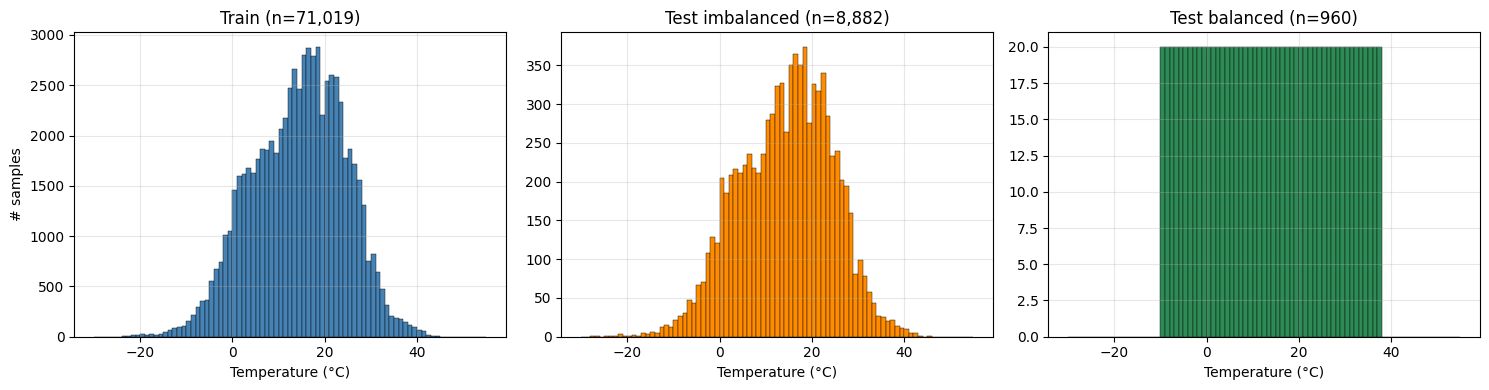


Plot saved to: /content/drive/MyDrive/Colab Notebooks/SkyFinder/data/split_distribution.png

Done.


In [ ]:
# ============================================================================
# Split — Scheme B (dual test sets) — build skyfinder_split.csv
# ----------------------------------------------------------------------------
# Method:
#   - Train/Val: stratified 80/10 split by 10°C bands
#   - Test (10%) split into:
#       test_imbalanced: original distribution (Chu et al.)
#       test_balanced: N=20 per bin (DIR-style few-shot)
#         - bins with <20 samples excluded from balanced
#   - test_balanced is a subset of test_imbalanced
#     marked by `in_test_balanced` (bool)
#   - Shot buckets based on train bin counts (100/20 and 1000/200)
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---- Paths ----
OUT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/SkyFinder/data")
CLEAN_CSV = OUT_DIR / "skyfinder_clean.csv"
SPLIT_CSV = OUT_DIR / "skyfinder_split.csv"
PLOT_PATH = OUT_DIR / "split_distribution.png"

# ---- Params ----
BIN_WIDTH = 1.0
TEMP_MIN = -30
TEMP_MAX = 55
STRATIFY_BAND = 10.0
SEED = 42
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10

rng = np.random.default_rng(SEED)

# ---- Load ----
df = pd.read_csv(CLEAN_CSV)
print(f"Loaded {len(df):,} rows from {CLEAN_CSV.name}")
print(f"Temperature range: [{df.temperature_c.min():.1f}, {df.temperature_c.max():.1f}]°C")

# ----------------------------------------------------------------------------
# Step 1: Stratified split (80/10/10)
# ----------------------------------------------------------------------------
df["_strat_band"] = pd.cut(
    df["temperature_c"],
    bins=np.arange(TEMP_MIN, TEMP_MAX + STRATIFY_BAND, STRATIFY_BAND),
    labels=False,
    include_lowest=True,
)

df["split"] = "train"
for band_id, group in df.groupby("_strat_band"):
    idx = group.index.to_numpy().copy()
    rng.shuffle(idx)
    n = len(idx)
    n_train = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)
    df.loc[idx[n_train:n_train + n_val], "split"] = "val"
    df.loc[idx[n_train + n_val:], "split"] = "test_imbalanced"

df = df.drop(columns=["_strat_band"])

print("\nStep 1 — stratified split done:")
print(df["split"].value_counts())

# ----------------------------------------------------------------------------
# Step 2: Build test_balanced from test_imbalanced
# ----------------------------------------------------------------------------
test_df = df[df["split"] == "test_imbalanced"].copy()
test_df["_bin"] = np.floor(test_df["temperature_c"] / BIN_WIDTH).astype(int)

bin_counts = test_df["_bin"].value_counts().sort_index()
print(f"\nTest set covers {len(bin_counts)} bins")
print(f"Sparsest bin: {bin_counts.min()} samples")
print(f"Densest bin:  {bin_counts.max()} samples")

N_PER_BIN = 20
eligible_bins = bin_counts[bin_counts >= N_PER_BIN].index.tolist()

print(f"\n→ test_balanced: N = {N_PER_BIN}")
print(f"   eligible bins: {len(eligible_bins)} / {len(bin_counts)}")

df["in_test_balanced"] = False
for bin_id in eligible_bins:
    group = test_df[test_df["_bin"] == bin_id]
    idx = group.index.to_numpy().copy()
    rng.shuffle(idx)
    df.loc[idx[:N_PER_BIN], "in_test_balanced"] = True

# ----------------------------------------------------------------------------
# Step 3: Shot buckets (based on train bins)
# ----------------------------------------------------------------------------
train_df = df[df["split"] == "train"].copy()
train_df["_bin"] = np.floor(train_df["temperature_c"] / BIN_WIDTH).astype(int)
train_bin_counts = train_df["_bin"].value_counts().sort_index()

def assign_shot(bin_count, many_thresh, med_thresh):
    if bin_count >= many_thresh:
        return "many"
    elif bin_count >= med_thresh:
        return "medium"
    else:
        return "few"

b2s_100_20 = {b: assign_shot(c, 100, 20) for b, c in train_bin_counts.items()}
b2s_1000_200 = {b: assign_shot(c, 1000, 200) for b, c in train_bin_counts.items()}

df["_bin"] = np.floor(df["temperature_c"] / BIN_WIDTH).astype(int)
df["shot_100_20"] = df["_bin"].map(b2s_100_20).fillna("few")
df["shot_1000_200"] = df["_bin"].map(b2s_1000_200).fillna("few")
df = df.drop(columns=["_bin"])

print("\nStep 3 — shot distribution:")
print("  100/20:")
for shot in ["many", "medium", "few"]:
    nb = sum(1 for s in b2s_100_20.values() if s == shot)
    ns = (train_df["_bin"].map(b2s_100_20) == shot).sum()
    print(f"    {shot:6s}: {nb:3d} bins, {ns:6,}")

print("  1000/200:")
for shot in ["many", "medium", "few"]:
    nb = sum(1 for s in b2s_1000_200.values() if s == shot)
    ns = (train_df["_bin"].map(b2s_1000_200) == shot).sum()
    print(f"    {shot:6s}: {nb:3d} bins, {ns:6,}")

# ----------------------------------------------------------------------------
# Step 4: Save + visualize
# ----------------------------------------------------------------------------
n_train = (df["split"] == "train").sum()
n_val = (df["split"] == "val").sum()
n_test_imb = (df["split"] == "test_imbalanced").sum()
n_test_bal = df["in_test_balanced"].sum()

print("\n" + "=" * 60)
print("Final split summary")
print("=" * 60)
print(f"  train:            {n_train:6,}")
print(f"  val:              {n_val:6,}")
print(f"  test_imbalanced:  {n_test_imb:6,}")
print(f"  test_balanced:    {n_test_bal:6,}")

df.to_csv(SPLIT_CSV, index=False)
print(f"\nSaved to: {SPLIT_CSV}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bins_viz = np.arange(TEMP_MIN, TEMP_MAX + BIN_WIDTH, BIN_WIDTH)

axes[0].hist(df[df.split == "train"]["temperature_c"], bins=bins_viz,
             color="steelblue", edgecolor="black", linewidth=0.3)
axes[0].set_title(f"Train (n={n_train:,})")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("# samples")
axes[0].grid(alpha=0.3)

axes[1].hist(df[df.split == "test_imbalanced"]["temperature_c"], bins=bins_viz,
             color="darkorange", edgecolor="black", linewidth=0.3)
axes[1].set_title(f"Test imbalanced (n={n_test_imb:,})")
axes[1].set_xlabel("Temperature (°C)")
axes[1].grid(alpha=0.3)

axes[2].hist(df[df.in_test_balanced]["temperature_c"], bins=bins_viz,
             color="seagreen", edgecolor="black", linewidth=0.3)
axes[2].set_title(f"Test balanced (n={n_test_bal:,})")
axes[2].set_xlabel("Temperature (°C)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=100, bbox_inches="tight")
plt.show()

print(f"\nPlot saved to: {PLOT_PATH}")
print("\nDone.")



In [ ]:
# ---- FORCE SAVE (robust) ----
import os

os.makedirs(OUT_DIR, exist_ok=True)

# 1) Save again to Drive (ensure write)
df.to_csv(SPLIT_CSV, index=False)

# 2) Save locally (backup)
df.to_csv("/content/skyfinder_split.csv", index=False)

# 3) Copy local → Drive (most reliable)
!cp /content/skyfinder_split.csv "/content/drive/MyDrive/Colab Notebooks/SkyFinder/data/"

# 4) Verify
print("\nCheck Drive data folder:")
print(os.listdir("/content/drive/MyDrive/Colab Notebooks/SkyFinder/data"))


Check Drive data folder:
['skyfinder_clean.csv', 'skyfinder_split.csv', 'split_distribution.png']
